# Task 3: Cleaning Data


## 1. Project Objective

### The objective of this project is to clean and preprocess a messy Titanic dataset and transform it into a clean, analysis-ready dataset.

### The cleaning process includes:
### - Identifying missing values
### - Detecting and removing duplicate rows
### - Standardising inconsistent data formats
### - Detecting and handling outliers
### - Correcting data types
### - Comparing the dataset before and after cleaning
### - Saving the cleaned dataset as a new CSV file

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load Dataset

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 4. Initial Data Inspection

### Dataset Shape

In [3]:
df.shape

(891, 12)

### Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 5. Data Quality Report

#### -> This section evaluates the quality of the raw dataset by checking missing values, duplicate rows, data types, and potential value range anomalies before cleaning.

### Missing Values per Column

In [5]:
missing_values = df.isnull().sum()

missing_values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Duplicate Rows

In [6]:
duplicate_count = df.duplicated().sum()

duplicate_count

np.int64(0)

### Data Types

In [7]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

### Numerical Value Ranges

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 6. Missing Data Handling

### The raw dataset contains missing values in the Age, Cabin, and Embarked columns. Different strategies are selected based on the nature and proportion of missing data.

- **Age:** Median imputation is selected because Age is a numerical variable and the median is less sensitive to extreme values than the mean.
- **Embarked:** Mode imputation is selected because Embarked is a categorical variable and only two values are missing.
- **Cabin:** More than 75% of the Cabin values are missing. Imputing such a large proportion would introduce unreliable information. Therefore, the Cabin column will be removed rather than deleting a large number of passenger records.

### Handling Missing Age Values

In [9]:
# Fill missing Age values with the median
age_median = df['Age'].median()

df['Age'] = df['Age'].fillna(age_median)

print("Median Age used for imputation:", age_median)
print("Remaining missing Age values:", df['Age'].isnull().sum())

Median Age used for imputation: 28.0
Remaining missing Age values: 0


### Handling Missing Embarked Values

In [10]:
# Fill missing Embarked values with the mode
embarked_mode = df['Embarked'].mode()[0]

df['Embarked'] = df['Embarked'].fillna(embarked_mode)

print("Mode used for imputation:", embarked_mode)
print("Remaining missing Embarked values:", df['Embarked'].isnull().sum())

Mode used for imputation: S
Remaining missing Embarked values: 0


### Handling Missing Cabin Values

In [11]:
# Check the proportion of missing Cabin values
cabin_missing_percentage = df['Cabin'].isnull().mean() * 100

print("Missing Cabin percentage:", cabin_missing_percentage)

Missing Cabin percentage: 77.10437710437711


In [12]:
# Remove Cabin because most values are missing
df = df.drop(columns=['Cabin'])

print("Cabin column removed.")

Cabin column removed.


### Missing Value Check After Initial Treatment

In [13]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## **Observation**

### Age and Embarked missing values were successfully handled using median and mode imputation respectively. The Cabin column was removed because most of its values were missing, and retaining or imputing such a large proportion of missing entries could reduce data quality. The resulting dataset has substantially fewer missing values.

## 7. Duplicate Removal

#### Duplicate rows can lead to repeated records and may distort analysis. The dataset will be checked for duplicate rows and any duplicates will be removed.

In [14]:
# Count duplicate rows before removal
duplicate_count = df.duplicated().sum()

print("Duplicate rows before removal:", duplicate_count)

Duplicate rows before removal: 0


### Remove Duplicate Rows

In [15]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape after duplicate removal:", df.shape)

Dataset shape after duplicate removal: (891, 11)


### **Observation**

### The dataset contained 0 duplicate rows before cleaning, so no rows were removed during duplicate removal.

## 8. Data Standardisation

#### Standardisation ensures that categorical and other text values follow a consistent format. This makes the dataset easier to analyse and prevents the same category from being treated as different values because of formatting differences.

### Check Categorical Values

In [16]:
print("Unique values in Sex:")
print(df['Sex'].unique())

print("\nUnique values in Embarked:")
print(df['Embarked'].unique())

Unique values in Sex:
['male' 'female']

Unique values in Embarked:
['S' 'C' 'Q']


### Standardise Text Formatting

In [17]:
# Remove leading/trailing spaces and standardise text case
df['Sex'] = df['Sex'].astype(str).str.strip().str.lower()
df['Embarked'] = df['Embarked'].astype(str).str.strip().str.upper()

# Convert Sex values to title case
df['Sex'] = df['Sex'].str.capitalize()

print("Standardised Sex values:", df['Sex'].unique())
print("Standardised Embarked values:", df['Embarked'].unique())

Standardised Sex values: ['Male' 'Female']
Standardised Embarked values: ['S' 'C' 'Q']


### ***Observation***

### The categorical columns were standardised to maintain consistent formatting. Sex values use a consistent capitalization style, while Embarked values use uppercase codes.

### Date Format Check

### The dataset does not contain a date column, so date-to-datetime conversion is not applicable to this dataset.

## 9. Outlier Detection

#### The Interquartile Range (IQR) method is used to identify potential outliers in numerical columns. Outliers will be reviewed before deciding whether they should be retained, capped, or removed.

### Numerical Columns for Outlier Detection

In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numeric_columns))

Numerical columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


### IQR-Based Outlier Detection

In [19]:
outlier_summary = {}

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    outlier_summary[column] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers)
    }

outlier_summary_df = pd.DataFrame(outlier_summary).T
outlier_summary_df

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
PassengerId,223.5000,668.5,445.0000,-444.000,1336.0000,0.0
Survived,0.0000,1.0,1.0000,-1.500,2.5000,0.0
Pclass,2.0000,3.0,1.0000,0.500,4.5000,0.0
Age,22.0000,35.0,13.0000,2.500,54.5000,66.0
SibSp,0.0000,1.0,1.0000,-1.500,2.5000,46.0
Parch,0.0000,0.0,0.0000,0.000,0.0000,213.0
Fare,7.9104,31.0,23.0896,-26.724,65.6344,116.0


### Boxplots for Outlier Inspection

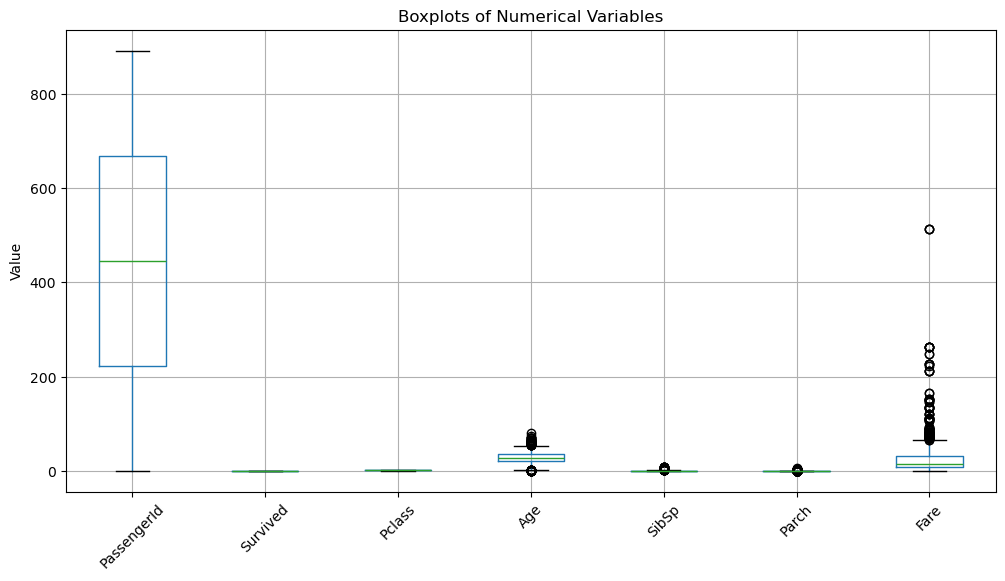

In [20]:
plt.figure(figsize=(12, 6))

df[numeric_columns].boxplot()

plt.title('Boxplots of Numerical Variables')
plt.xticks(rotation=45)
plt.ylabel('Value')

plt.show()

### Outlier Treatment Decision

#### The PassengerId column is excluded from outlier analysis because it is an identifier rather than a meaningful continuous numerical variable. Survived and Pclass are categorical/discrete variables, so IQR-based outlier treatment is not appropriate for them.

#### Potential outliers in Age, Fare, SibSp, and Parch are reviewed based on domain context. Extreme values in the Titanic dataset may represent genuine passenger characteristics or ticket prices rather than data-entry errors.

In [21]:
# Focus on meaningful numerical variables for outlier analysis
outlier_columns = ['Age', 'Fare', 'SibSp', 'Parch']

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"{column}: {len(outliers)} potential outliers")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print()

Age: 66 potential outliers
Lower Bound: 2.50
Upper Bound: 54.50

Fare: 116 potential outliers
Lower Bound: -26.72
Upper Bound: 65.63

SibSp: 46 potential outliers
Lower Bound: -1.50
Upper Bound: 2.50

Parch: 213 potential outliers
Lower Bound: 0.00
Upper Bound: 0.00



### Outlier Handling Decision

#### The detected outliers are retained because the extreme values are plausible observations rather than clear data-entry errors. For example, higher Fare values can represent expensive passenger tickets, while higher Age values can still represent valid passenger ages. Removing these observations without evidence could result in loss of meaningful information.

## 10. Data Type Correction

### The dataset types are reviewed to ensure that each column uses an appropriate data type for analysis. Identifier fields are converted to strings, numerical fields are kept numeric, and categorical fields are kept as strings.

### Current Data Types

In [22]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

### Correct Data Types

In [23]:
# PassengerId and Ticket are identifiers
df['PassengerId'] = df['PassengerId'].astype(str)
df['Ticket'] = df['Ticket'].astype(str)

# Categorical columns
df['Survived'] = df['Survived'].astype(int)
df['Pclass'] = df['Pclass'].astype(int)
df['SibSp'] = df['SibSp'].astype(int)
df['Parch'] = df['Parch'].astype(int)

# Numeric columns
df['Age'] = df['Age'].astype(float)
df['Fare'] = df['Fare'].astype(float)

# Text columns
df['Name'] = df['Name'].astype(str)
df['Sex'] = df['Sex'].astype(str)
df['Embarked'] = df['Embarked'].astype(str)

df.dtypes

PassengerId     object
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

### **Observation**

### The data types were corrected according to the meaning of each column. PassengerId and Ticket are treated as identifiers, numerical variables remain numeric, and categorical variables are stored as text.

### Final Data Type Check

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    object 
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


## 11. Before vs After Cleaning Summary

### This section compares the dataset before and after cleaning using null count, duplicate count, row count, and data type accuracy.

In [25]:
# Create before vs after summary

before_null_count = 866
before_duplicate_count = 0
before_row_count = 891
before_dtype_accuracy = "Needs correction"

after_null_count = df.isnull().sum().sum()
after_duplicate_count = df.duplicated().sum()
after_row_count = len(df)
after_dtype_accuracy = "Corrected"

summary = pd.DataFrame({
    'Metric': [
        'Null Count',
        'Duplicate Count',
        'Row Count',
        'Dtype Accuracy'
    ],
    'Before Cleaning': [
        before_null_count,
        before_duplicate_count,
        before_row_count,
        before_dtype_accuracy
    ],
    'After Cleaning': [
        after_null_count,
        after_duplicate_count,
        after_row_count,
        after_dtype_accuracy
    ]
})

summary

,Metric,Before Cleaning,After Cleaning
0,Null Count,866,0
1,Duplicate Count,0,0
2,Row Count,891,891
3,Dtype Accuracy,Needs correction,Corrected


### Observation

#### The cleaning process reduced the total number of missing values from 866 to 0. No duplicate rows were present before or after cleaning, so no duplicate records were removed. The row count remained 891 because missing values were handled through imputation and column removal rather than deleting passenger records. Data types were corrected to improve analysis readiness.

### Final Data Validation

In [26]:
print("Final shape:", df.shape)
print("\nRemaining missing values:")
print(df.isnull().sum())

print("\nRemaining duplicate rows:", df.duplicated().sum())

Final shape: (891, 11)

Remaining missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Remaining duplicate rows: 0


## 12. Save Cleaned Dataset

In [27]:
df.to_csv("cleaned_titanic_dataset.csv", index=False)

print("Cleaned dataset saved successfully as 'cleaned_titanic_dataset.csv'")

Cleaned dataset saved successfully as 'cleaned_titanic_dataset.csv'


### Check that it saved

In [29]:
import os

print(os.path.exists("cleaned_titanic_dataset.csv"))

True


## 14. **Conclusion**

### The Titanic dataset was systematically cleaned and transformed into an analysis-ready dataset.

### The cleaning process included:
#### - Identifying and handling missing values using appropriate strategies.
#### - Removing duplicate rows after checking for duplicates.
#### - Standardising categorical values.
#### - Detecting potential outliers using the IQR method and retaining plausible observations.
#### - Correcting data types for identifiers, numerical variables, and categorical variables.
#### - Comparing the dataset before and after cleaning.
#### - Saving the final cleaned dataset as a new CSV file.

#### After cleaning, all missing values were resolved, no duplicate rows were present, and the dataset retained 891 rows for further analysis.